<a href="https://colab.research.google.com/github/IbnuArif401/flight-delay-prediction/blob/main/flight-delay-prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
#Memuat Data
df = pd.read_csv('Airline Delay2020.csv')
print(df.head())
df.head()

   year  month carrier       carrier_name airport  \
0  2020     12      9E  Endeavor Air Inc.     ABE   
1  2020     12      9E  Endeavor Air Inc.     ABY   
2  2020     12      9E  Endeavor Air Inc.     AEX   
3  2020     12      9E  Endeavor Air Inc.     AGS   
4  2020     12      9E  Endeavor Air Inc.     ALB   

                                        airport_name  arr_flights  arr_del15  \
0  Allentown/Bethlehem/Easton, PA: Lehigh Valley ...         44.0        3.0   
1             Albany, GA: Southwest Georgia Regional         90.0        1.0   
2           Alexandria, LA: Alexandria International         88.0        8.0   
3        Augusta, GA: Augusta Regional at Bush Field        184.0        9.0   
4                   Albany, NY: Albany International         76.0       11.0   

   carrier_ct  weather_ct  ...  security_ct  late_aircraft_ct  arr_cancelled  \
0        1.63         0.0  ...          0.0              1.25            0.0   
1        0.96         0.0  ...          

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2020,12,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",44.0,3.0,1.63,0.0,...,0.0,1.25,0.0,1.0,89.0,56.0,0.0,3.0,0.0,30.0
1,2020,12,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",90.0,1.0,0.96,0.0,...,0.0,0.00,0.0,0.0,23.0,22.0,0.0,1.0,0.0,0.0
2,2020,12,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",88.0,8.0,5.75,0.0,...,0.0,0.65,0.0,1.0,338.0,265.0,0.0,45.0,0.0,28.0
3,2020,12,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",184.0,9.0,4.17,0.0,...,0.0,3.00,0.0,0.0,508.0,192.0,0.0,92.0,0.0,224.0
4,2020,12,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",76.0,11.0,4.78,0.0,...,0.0,1.00,1.0,0.0,692.0,398.0,0.0,178.0,0.0,116.0


In [ ]:
def check_csv_columns(csv_file):
    with open(csv_file, mode='r', encoding='utf-8') as file:
        reader = csv.reader(file)
        header = next(reader)  # Baca header (baris pertama yang berisi nama kolom)
        print("Nama-nama kolom dalam file CSV:")
        print(header)

# Ganti path atau nama file CSV dengan yang sesuai di komputer Anda
csv_file = "Airline Delay2020.csv"

check_csv_columns(csv_file)


Nama-nama kolom dalam file CSV:
['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name', 'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']


In [ ]:
# Meninjau Data
# Menampilkan informasi umum tentang dataset
print(data.info())

# Menampilkan statistik deskriptif dari dataset
print(data.describe())


<class 'pandas.core.frame.DataFrame'>
Index: 3343 entries, 0 to 3350
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 3343 non-null   int64  
 1   month                3343 non-null   int64  
 2   carrier              3343 non-null   object 
 3   carrier_name         3343 non-null   object 
 4   airport              3343 non-null   object 
 5   airport_name         3343 non-null   object 
 6   arr_flights          3343 non-null   float64
 7   arr_del15            3343 non-null   float64
 8   carrier_ct           3343 non-null   float64
 9   weather_ct           3343 non-null   float64
 10  nas_ct               3343 non-null   float64
 11  security_ct          3343 non-null   float64
 12  late_aircraft_ct     3343 non-null   float64
 13  arr_cancelled        3343 non-null   float64
 14  arr_diverted         3343 non-null   float64
 15  arr_delay            3343 non-null   float6

In [ ]:
# Pembersihan Data
# Menghapus baris duplikat
data = data.drop_duplicates()

# Menangani nilai yang hilang
# Melihat jumlah nilai yang hilang untuk setiap kolom
print(data.isnull().sum())

# Mengisi nilai yang hilang atau menghapus baris/kolom dengan nilai yang hilang
# Sebagai contoh, kita akan menghapus baris dengan nilai yang hilang
data = data.dropna()

# Menampilkan informasi umum tentang dataset setelah pembersihan
print(data.info())


year                   0
month                  0
carrier                0
carrier_name           0
airport                0
airport_name           0
arr_flights            0
arr_del15              0
carrier_ct             0
weather_ct             0
nas_ct                 0
security_ct            0
late_aircraft_ct       0
arr_cancelled          0
arr_diverted           0
arr_delay              0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 3343 entries, 0 to 3350
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 3343 non-null   int64  
 1   month                3343 non-null   int64  
 2   carrier              3343 non-null   object 
 3   carrier_name         3343 non-null   object 
 4   airport              3343 non-null   object 
 5   airpo

In [ ]:
#Analisis Eksploratif (EDA)
# Menampilkan statistik deskriptif dari dataset
print(data.describe())


              year   month   arr_flights    arr_del15   carrier_ct  \
count  3343.000000  3343.0   3343.000000  3343.000000  3343.000000   
mean   2019.458271    12.0    298.271014    50.995214    16.065337   
std       0.498330     0.0    852.436335   146.484456    41.759516   
min    2019.000000    12.0      1.000000     0.000000     0.000000   
25%    2019.000000    12.0     35.000000     5.000000     1.490000   
50%    2019.000000    12.0     83.000000    12.000000     4.750000   
75%    2020.000000    12.0    194.500000    33.000000    12.255000   
max    2020.000000    12.0  19713.000000  2289.000000   697.000000   

        weather_ct       nas_ct  security_ct  late_aircraft_ct  arr_cancelled  \
count  3343.000000  3343.000000  3343.000000       3343.000000    3343.000000   
mean      1.443144    16.183383     0.137320         17.166069       2.884535   
std       4.821657    56.423008     0.646479         55.447043      10.126658   
min       0.000000     0.000000     0.000000 

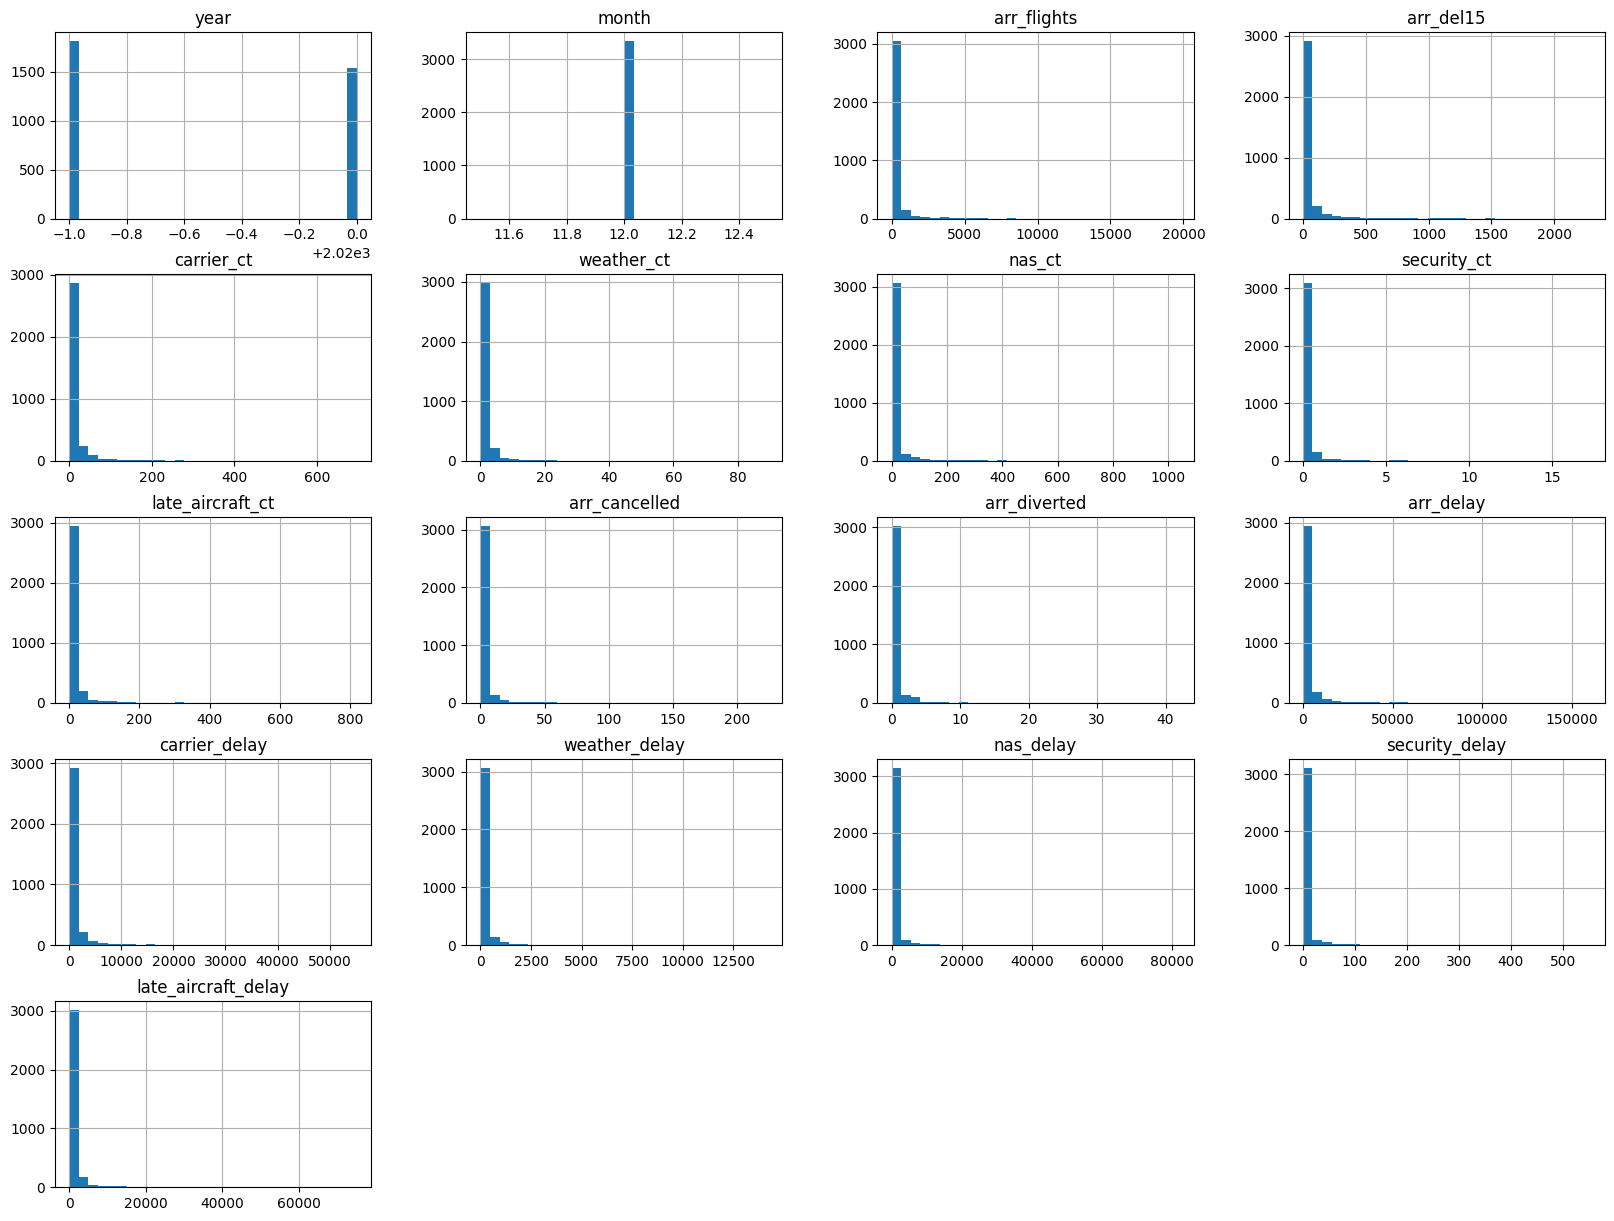

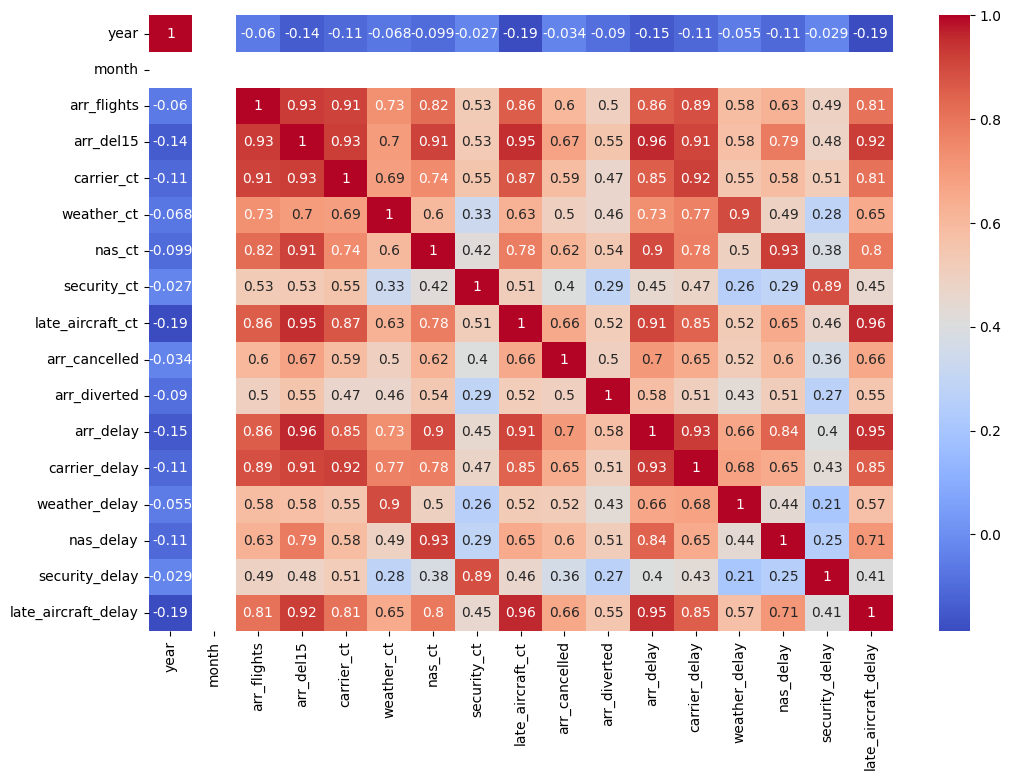

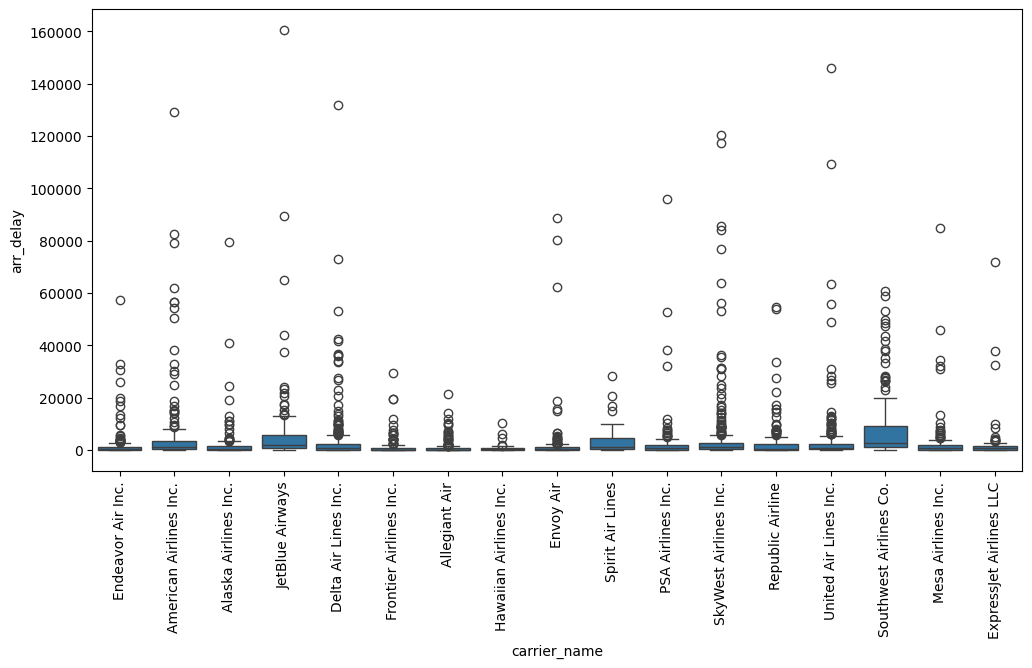

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram untuk setiap kolom numerik
data.hist(bins=30, figsize=(20, 15))
plt.show()

# Memilih hanya kolom numerik
numeric_data = data.select_dtypes(include=['number'])

# Heatmap dari korelasi antara variabel numerik
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.show()

# Visualisasi tambahan sesuai kebutuhan, misalnya distribusi delay berdasarkan maskapai
plt.figure(figsize=(12, 6))
sns.boxplot(x='carrier_name', y='arr_delay', data=data)
plt.xticks(rotation=90)
plt.show()


Pembagian Data: Membagi dataset menjadi set pelatihan dan pengujian.
Membangun Model: Menggunakan algoritma pembelajaran mesin untuk membangun model prediktif.
Evaluasi Model: Mengevaluasi kinerja model menggunakan metrik yang sesuai.
Sebagai contoh, kita akan membangun model regresi linear untuk memprediksi keterlambatan kedatangan (arr_delay) berdasarkan beberapa fitur yang tersedia.

   year  month carrier       carrier_name airport  \
0  2020     12      9E  Endeavor Air Inc.     ABE   
1  2020     12      9E  Endeavor Air Inc.     ABY   
2  2020     12      9E  Endeavor Air Inc.     AEX   
3  2020     12      9E  Endeavor Air Inc.     AGS   
4  2020     12      9E  Endeavor Air Inc.     ALB   

                                        airport_name  arr_flights  arr_del15  \
0  Allentown/Bethlehem/Easton, PA: Lehigh Valley ...         44.0        3.0   
1             Albany, GA: Southwest Georgia Regional         90.0        1.0   
2           Alexandria, LA: Alexandria International         88.0        8.0   
3        Augusta, GA: Augusta Regional at Bush Field        184.0        9.0   
4                   Albany, NY: Albany International         76.0       11.0   

   carrier_ct  weather_ct  ...  security_ct  late_aircraft_ct  arr_cancelled  \
0        1.63         0.0  ...          0.0              1.25            0.0   
1        0.96         0.0  ...          

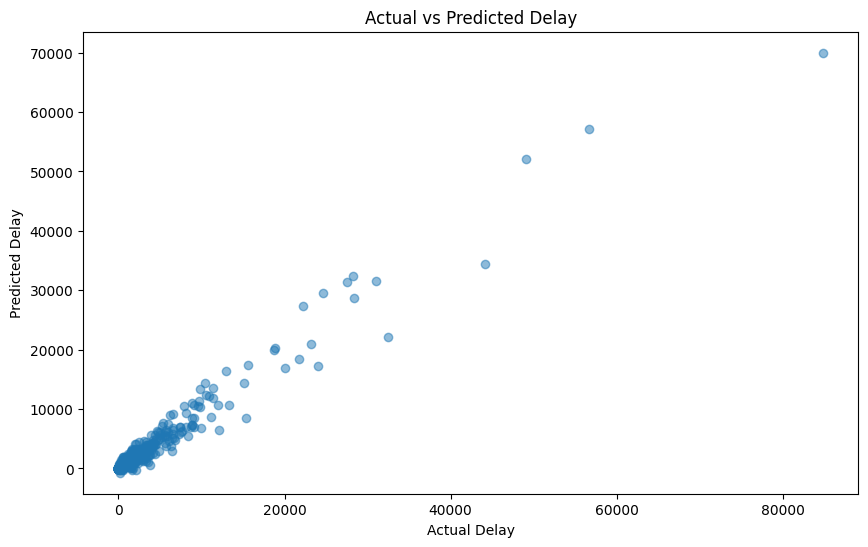

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Memuat data dari file CSV
file_path = 'Airline Delay2020.csv'
data = pd.read_csv(file_path)

# Menampilkan beberapa baris pertama dari dataset
print(data.head())

# Menampilkan semua nama kolom dalam dataset
print(data.columns)

# Menampilkan informasi umum tentang dataset
print(data.info())

# Menghapus baris duplikat
data = data.drop_duplicates()

# Menangani nilai yang hilang
data = data.dropna()

# Memilih fitur dan target
features = ['year', 'month', 'arr_flights', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct']
target = 'arr_delay'

X = data[features]
y = data[target]

# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Membuat model regresi linear
model = LinearRegression()
model.fit(X_train, y_train)

# Memprediksi pada set pengujian
y_pred = model.predict(X_test)

# Mengevaluasi model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

# Visualisasi hasil prediksi vs nilai aktual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Delay')
plt.ylabel('Predicted Delay')
plt.title('Actual vs Predicted Delay')
plt.show()


In [ ]:
# Import library yang dibutuhkan
import numpy as np
from sklearn.linear_model import LinearRegression

# Data latih (contoh)
X_train = np.array([[1], [2], [3], [4], [5]])  # contoh fitur
y_train = np.array([2, 4, 5, 4, 5])  # contoh target

# Membuat model regresi linear
model = LinearRegression()

# Melatih model
model.fit(X_train, y_train)

# Contoh prediksi
X_new = np.array([[6], [7]])  # data baru untuk diprediksi
predictions = model.predict(X_new)

# Menampilkan hasil prediksi
print("Prediksi:", predictions)


Prediksi: [5.8 6.4]


In [ ]:
import csv

def get_top_airlines(csv_file, num_airlines=10):
    top_airlines = []
    with open(csv_file, mode='r', encoding='utf-8') as file:
        reader = csv.DictReader(file)
        airlines_data = list(reader)

        # Hitung ukuran armada berdasarkan jumlah penerbangan atau data lain yang relevan
        # Di sini, kita menggunakan contoh dengan menghitung jumlah penerbangan
        airline_counts = {}
        for row in airlines_data:
            carrier_name = row['carrier_name']  # Ganti dengan kolom yang sesuai
            if carrier_name in airline_counts:
                airline_counts[carrier_name] += 1
            else:
                airline_counts[carrier_name] = 1

        # Urutkan berdasarkan ukuran armada (jumlah penerbangan)
        sorted_airlines = sorted(airline_counts.items(), key=lambda x: x[1], reverse=True)

        # Ambil 10 maskapai penerbangan teratas
        for airline, count in sorted_airlines[:num_airlines]:
            top_airlines.append(airline)

    return top_airlines

# Ganti path atau nama file CSV dengan yang sesuai di komputer Anda
csv_file = "Airline Delay2020.csv"

# Dapatkan 10 maskapai penerbangan terbesar dari file CSV
top_airlines = get_top_airlines(csv_file, 10)
for index, name in enumerate(top_airlines, start=1):
    print(f"{index}. {name}")


1. SkyWest Airlines Inc.
2. Envoy Air
3. Delta Air Lines Inc.
4. Allegiant Air
5. Endeavor Air Inc.
6. Mesa Airlines Inc.
7. American Airlines Inc.
8. Republic Airline
9. United Air Lines Inc.
10. PSA Airlines Inc.


In [ ]:
# Statistik deskriptif untuk data numerik
print(df.describe())

# Jumlah baris dan kolom dalam dataset
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")


              year   month   arr_flights    arr_del15   carrier_ct  \
count  3351.000000  3351.0   3343.000000  3343.000000  3343.000000   
mean   2019.459266    12.0    298.271014    50.995214    16.065337   
std       0.498412     0.0    852.436335   146.484456    41.759516   
min    2019.000000    12.0      1.000000     0.000000     0.000000   
25%    2019.000000    12.0     35.000000     5.000000     1.490000   
50%    2019.000000    12.0     83.000000    12.000000     4.750000   
75%    2020.000000    12.0    194.500000    33.000000    12.255000   
max    2020.000000    12.0  19713.000000  2289.000000   697.000000   

        weather_ct       nas_ct  security_ct  late_aircraft_ct  arr_cancelled  \
count  3343.000000  3343.000000  3343.000000       3343.000000    3343.000000   
mean      1.443144    16.183383     0.137320         17.166069       2.884535   
std       4.821657    56.423008     0.646479         55.447043      10.126658   
min       0.000000     0.000000     0.000000 

In [ ]:
# Menemukan jumlah dan persentase nilai-nilai yang hilang di setiap kolom
missing_values = df.isnull().sum()
missing_percent = (missing_values / df.shape[0]) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percent': missing_percent
})
print(missing_df)


                     Missing Values  Missing Percent
year                              0         0.000000
month                             0         0.000000
carrier                           0         0.000000
carrier_name                      0         0.000000
airport                           0         0.000000
airport_name                      0         0.000000
arr_flights                       8         0.238735
arr_del15                         8         0.238735
carrier_ct                        8         0.238735
weather_ct                        8         0.238735
nas_ct                            8         0.238735
security_ct                       8         0.238735
late_aircraft_ct                  8         0.238735
arr_cancelled                     8         0.238735
arr_diverted                      8         0.238735
arr_delay                         8         0.238735
carrier_delay                     8         0.238735
weather_delay                     8         0.

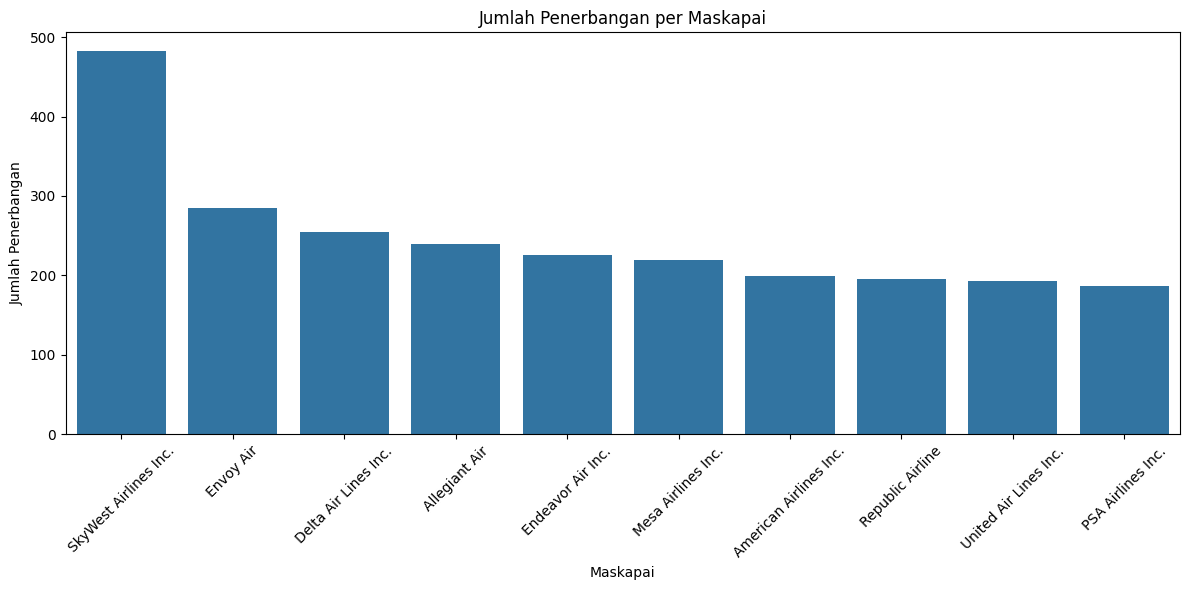

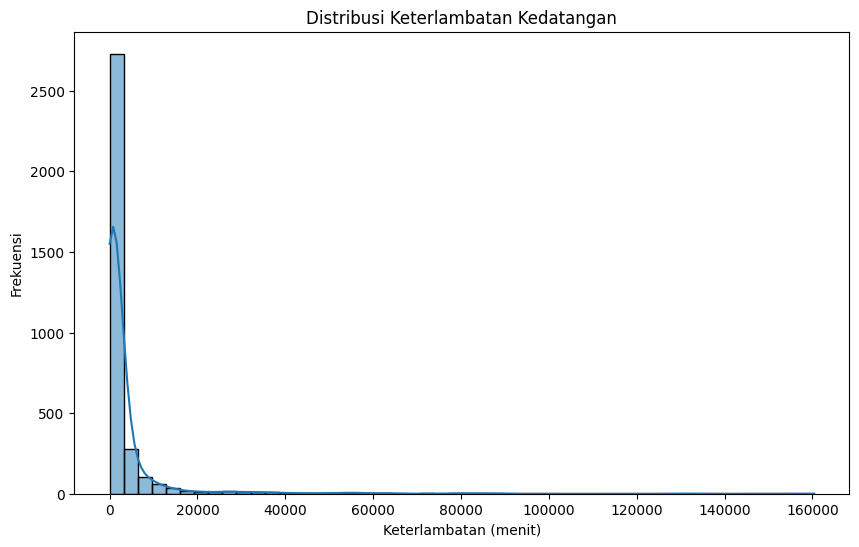

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contoh: Visualisasi jumlah penerbangan per maskapai
plt.figure(figsize=(12, 6))
sns.countplot(x='carrier_name', data=df, order=df['carrier_name'].value_counts().index[:10])
plt.title('Jumlah Penerbangan per Maskapai')
plt.xticks(rotation=45)
plt.xlabel('Maskapai')
plt.ylabel('Jumlah Penerbangan')
plt.tight_layout()
plt.show()

# Contoh: Distribusi keterlambatan penerbangan
plt.figure(figsize=(10, 6))
sns.histplot(df['arr_delay'], bins=50, kde=True)
plt.title('Distribusi Keterlambatan Kedatangan')
plt.xlabel('Keterlambatan (menit)')
plt.ylabel('Frekuensi')
plt.show()


5. Analisis Lebih Lanjut
Lakukan analisis lebih lanjut sesuai dengan tujuan dan pertanyaan Anda terhadap dataset, seperti:

Hubungan antara keterlambatan dan faktor-faktor lain seperti cuaca, alasan teknis, dll.
Perbandingan performa maskapai berdasarkan berbagai metrik (keterlambatan, jumlah penerbangan, dll.).
Perbandingan performa bandara atau rute tertentu.
6. Kesimpulan dan Rekomendasi
Buat kesimpulan dari hasil EDA dan ajukan rekomendasi berdasarkan wawasan yang Anda dapatkan dari data.

Dengan melakukan langkah-langkah di atas, Anda dapat memperoleh pemahaman yang lebih baik tentang dataset penerbangan Anda dan mengeksplorasi berbagai aspeknya secara lebih mendalam. Adjust the path








In [ ]:
# Menggunakan pandas dan numpy
import pandas as pd
import numpy as np

# Misalnya, kita ingin mendeteksi outlier pada kolom 'arr_delay'
arr_delay = df['arr_delay']

# Menghitung Q1, Q3, dan IQR
Q1 = arr_delay.quantile(0.25)
Q3 = arr_delay.quantile(0.75)
IQR = Q3 - Q1

# Menghitung batas bawah dan atas untuk outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mendeteksi outlier
outliers = arr_delay[(arr_delay < lower_bound) | (arr_delay > upper_bound)]
print("Jumlah outlier:", len(outliers))
print("Outlier:")
print(outliers)


Jumlah outlier: 414
Outlier:
5       30756.0
39      16873.0
84      19895.0
123      7217.0
130     30305.0
         ...   
3319     7715.0
3323    23181.0
3324    36694.0
3327    41721.0
3336    10203.0
Name: arr_delay, Length: 414, dtype: float64


Untuk mendeteksi outlier dalam dataset penerbangan, khususnya terkait dengan keterlambatan penerbangan, Anda dapat menggunakan metode statistik dan visualisasi. Outlier adalah nilai yang jauh berbeda dari sebagian besar data dalam dataset, dan mendeteksinya penting karena dapat memberikan wawasan tentang anomali atau masalah yang mungkin ada dalam data. Berikut ini beberapa langkah umum untuk mendeteksi outlier:

1. Menggunakan Metode Statistik
Menggunakan Metode IQR (Interquartile Range)
Metode IQR adalah salah satu metode yang umum digunakan untuk mendeteksi outlier. Berikut langkah-langkahnya:

Hitung Q1 (kuartil pertama) dan Q3 (kuartil ketiga).
Hitung IQR (Interquartile Range), yaitu selisih antara Q3 dan Q1.
Tentukan batas bawah (Q1 - 1.5 * IQR) dan batas atas (Q3 + 1.5 * IQR).
Nilai di luar batas ini dapat dianggap sebagai outlier.

2. Visualisasi untuk Mendeteksi Outlier
Boxplot
Boxplot adalah visualisasi yang baik untuk melihat distribusi data dan mendeteksi outlier secara visual.

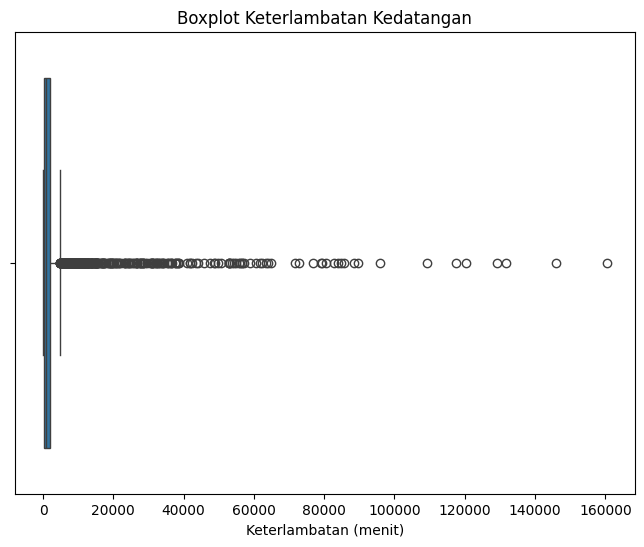

In [ ]:
# Menggunakan seaborn untuk boxplot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x=df['arr_delay'])
plt.title('Boxplot Keterlambatan Kedatangan')
plt.xlabel('Keterlambatan (menit)')
plt.show()


Dalam boxplot di atas, nilai-nilai yang berada di luar garis batas (garis horizontal di atas dan di bawah kotak) dapat dianggap sebagai outlier.

3. Adjusting for Different Needs
Jika dataset Anda memiliki atribut lain yang ingin Anda periksa untuk outlier, Anda bisa mengadaptasi metode ini dengan mengganti kolom atau atribut yang diperlukan. Outlier detection is crucial as it can indicate anomalies